In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
!nvidia-smi --query-gpu=name,memory.total --format=csv,noheader

import torch

print("CUDA disponibile:", torch.cuda.is_available())
print("Numero GPU:", torch.cuda.device_count())

for index in range(torch.cuda.device_count()):
    print(index, torch.cuda.get_device_name(index))

In [ ]:
!find /kaggle/input -maxdepth 4 -type f | head -50

In [ ]:
print("sessione attiva")

In [ ]:
from pathlib import Path

input_files = [
    path
    for path in Path("/kaggle/input").rglob("*")
    if path.is_file()
]

print("File trovati:", len(input_files))

for path in input_files[:50]:
    print(path)

In [2]:
import torch
import transformers
import huggingface_hub

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Hugging Face Hub:", huggingface_hub.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("BF16 supportato:", torch.cuda.is_bf16_supported())

PyTorch: 2.10.0+cu128
Transformers: 4.56.1
Hugging Face Hub: 0.36.2
GPU: Tesla T4
BF16 supportato: True


In [ ]:
%cd /kaggle/working

!test -d AnomalyVFM || git clone https://github.com/MaticFuc/AnomalyVFM.git

%cd /kaggle/working/AnomalyVFM
!git checkout 4da96b493a0b12e4e380fa5bf6573c126342855c

!pip install -q \
  "huggingface_hub==0.36.2" \
  "transformers==4.56.1" \
  "timm==1.0.25" \
  "einops==0.8.2" \
  safetensors

import torch
import transformers
import huggingface_hub

print("Commit AnomalyVFM:")
!git rev-parse HEAD

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Hugging Face Hub:", huggingface_hub.__version__)
print("GPU:", torch.cuda.get_device_name(0))
print("BF16 supportato:", torch.cuda.is_bf16_supported())

In [ ]:
import requests

response = requests.get("https://github.com", timeout=15)
print("Internet:", response.status_code)

In [3]:
from pathlib import Path
import subprocess

repo_path = Path("/kaggle/working/AnomalyVFM")

print("Repository presente:", repo_path.exists())

if repo_path.exists():
    commit = subprocess.check_output(
        ["git", "-C", str(repo_path), "rev-parse", "HEAD"],
        text=True,
    ).strip()
    print("Commit:", commit)

Repository presente: True
Commit: 4da96b493a0b12e4e380fa5bf6573c126342855c


In [4]:
%cd /kaggle/working/AnomalyVFM

import sys
from pathlib import Path
from huggingface_hub import model_info

sys.path.insert(0, "/kaggle/working/AnomalyVFM")

from hf_model import AnomalyVFM

DEVICE = torch.device("cuda:0")
HF_MODEL_ID = "MaticFuc/anomalyvfm_dinov2"

model_information = model_info(HF_MODEL_ID)
HF_REVISION = model_information.sha

print("Revisione pesi Hugging Face:", HF_REVISION)

anomalyvfm = AnomalyVFM.from_pretrained(
    HF_MODEL_ID,
    revision=HF_REVISION,
).to(DEVICE)

anomalyvfm.eval()
image_transform = anomalyvfm.model.get_img_transform()

parameter_count = sum(
    parameter.numel()
    for parameter in anomalyvfm.parameters()
)

print("Modello caricato:", HF_MODEL_ID)
print("Parametri:", parameter_count)
print(
    "Memoria GPU allocata:",
    round(torch.cuda.memory_allocated(0) / 1024**3, 2),
    "GB",
)
print("Device:", next(anomalyvfm.parameters()).device)

print("Commit repository:")
!git rev-parse HEAD

/kaggle/working/AnomalyVFM
Revisione pesi Hugging Face: c7698cefc6415ca43c93c3e924e02f6863c57e73


config.json:   0%|          | 0.00/158 [00:00<?, ?B/s]

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_reg4_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_reg4_pretrain.pth


100%|██████████| 1.13G/1.13G [00:03<00:00, 365MB/s]


model.safetensors:   0%|          | 0.00/1.36G [00:00<?, ?B/s]

Modello caricato: MaticFuc/anomalyvfm_dinov2
Parametri: 339847171
Memoria GPU allocata: 1.27 GB
Device: cuda:0
Commit repository:
4da96b493a0b12e4e380fa5bf6573c126342855c


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
import cv2
import shutil
import pandas as pd
from pathlib import Path

INPUT_ROOT = Path(
    "/kaggle/input/datasets/michelerais/"
    "thermal-thesis-e06-inputs/E05_inputs"
)

normal_dir = INPUT_ROOT / "normal_frames"
clip_path = (
    INPUT_ROOT
    / "test_clip"
    / "san_donato_pilot_85_105.mp4"
)
gt_path = (
    INPUT_ROOT
    / "annotations"
    / "test_video_san_donato_v2_reviewed_boxes.csv"
)

anomaly_frames_dir = Path(
    "/kaggle/working/E06_anomaly_frames"
)

if anomaly_frames_dir.exists():
    shutil.rmtree(anomaly_frames_dir)
anomaly_frames_dir.mkdir()

cap = cv2.VideoCapture(str(clip_path))
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = 0

while True:
    ok, frame = cap.read()
    if not ok:
        break

    cv2.imwrite(
        str(
            anomaly_frames_dir
            / f"anomaly_{frame_count:05d}.jpg"
        ),
        frame,
    )
    frame_count += 1

cap.release()

# Stessi 20 normali indipendenti usati come test primario in E05
normal_test_files = [
    normal_dir / f"normal_{index:04d}.jpg"
    for index in range(181, 201)
]

print("Frame anomali:", frame_count)
print(
    "Normali test presenti:",
    sum(path.exists() for path in normal_test_files),
)
print("FPS:", fps)
print("GT presente:", gt_path.exists())

Frame anomali: 500
Normali test presenti: 20
FPS: 24.999
GT presente: True


Normale — score: 0.470703125
Anomalo — score: 0.66015625
Forma maschera: (96, 96)
Tempo normale: 1.731 s
Tempo anomalo: 1.125 s


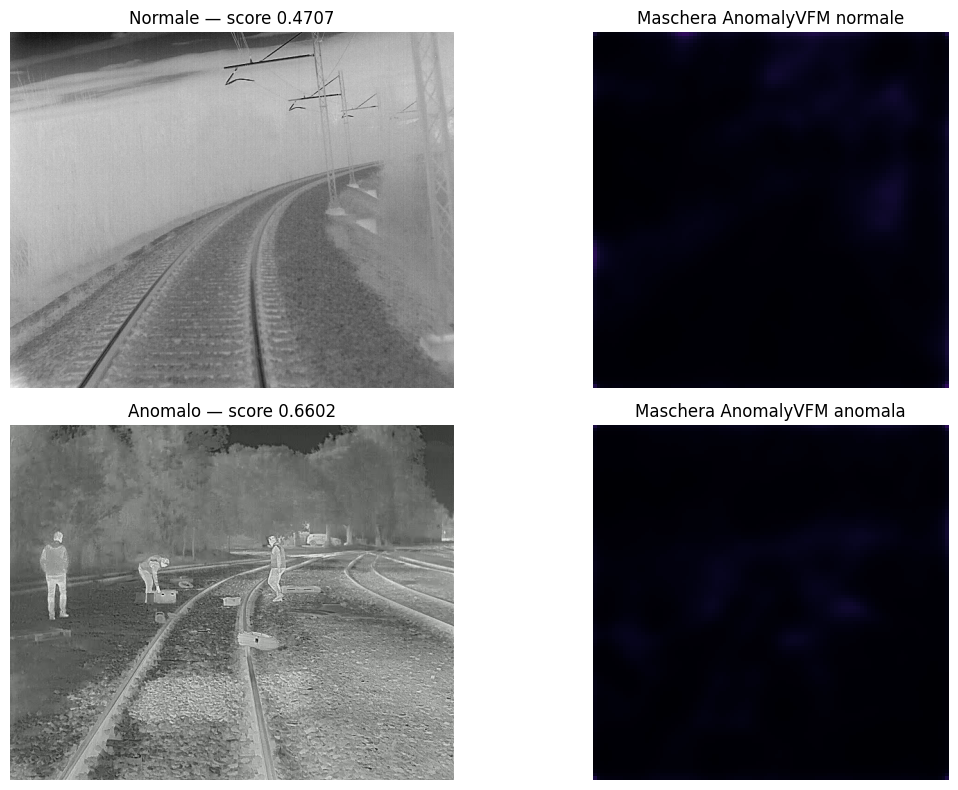

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def run_anomalyvfm(image_path):
    image = Image.open(image_path).convert("RGB")
    input_tensor = (
        image_transform(image)
        .unsqueeze(0)
        .to(DEVICE)
    )

    torch.cuda.synchronize()
    start = time.time()

    with torch.inference_mode():
        score, mask = anomalyvfm(input_tensor)

    torch.cuda.synchronize()
    elapsed = time.time() - start

    return (
        float(score.squeeze().cpu()),
        mask.squeeze().float().cpu().numpy(),
        elapsed,
    )


normal_probe = normal_dir / "normal_0186.jpg"
anomaly_probe = (
    anomaly_frames_dir / "anomaly_00300.jpg"
)

normal_score, normal_mask, normal_time = run_anomalyvfm(
    normal_probe
)
anomaly_score, anomaly_mask, anomaly_time = run_anomalyvfm(
    anomaly_probe
)

print("Normale — score:", normal_score)
print("Anomalo — score:", anomaly_score)
print("Forma maschera:", anomaly_mask.shape)
print("Tempo normale:", round(normal_time, 3), "s")
print("Tempo anomalo:", round(anomaly_time, 3), "s")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(Image.open(normal_probe))
axes[0, 0].set_title(f"Normale — score {normal_score:.4f}")

axes[0, 1].imshow(
    normal_mask,
    cmap="inferno",
    vmin=0,
    vmax=1,
)
axes[0, 1].set_title("Maschera AnomalyVFM normale")

axes[1, 0].imshow(Image.open(anomaly_probe))
axes[1, 0].set_title(f"Anomalo — score {anomaly_score:.4f}")

axes[1, 1].imshow(
    anomaly_mask,
    cmap="inferno",
    vmin=0,
    vmax=1,
)
axes[1, 1].set_title("Maschera AnomalyVFM anomala")

for axis in axes.ravel():
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    "/kaggle/working/E06_probe_normal_vs_anomaly.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [7]:
for name, mask in [
    ("normale", normal_mask),
    ("anomalo", anomaly_mask),
]:
    print(
        name,
        "min:", float(mask.min()),
        "mediana:", float(np.median(mask)),
        "p99:", float(np.quantile(mask, 0.99)),
        "max:", float(mask.max()),
    )

batch_images = torch.stack([
    image_transform(
        Image.open(normal_probe).convert("RGB")
    ),
    image_transform(
        Image.open(anomaly_probe).convert("RGB")
    ),
]).to(DEVICE)

torch.cuda.synchronize()
start = time.time()

with torch.inference_mode():
    batch_scores, batch_masks = anomalyvfm(batch_images)

torch.cuda.synchronize()
batch_seconds = time.time() - start

print("Score batch:", batch_scores.squeeze().cpu().tolist())
print("Forma maschere batch:", tuple(batch_masks.shape))
print("Tempo batch 2:", round(batch_seconds, 3), "s")
print(
    "Picco memoria GPU:",
    round(torch.cuda.max_memory_allocated(0) / 1024**3, 2),
    "GB",
)

normale min: 0.0028839111328125 mediana: 0.018310546875 p99: 0.078125 max: 0.1572265625
anomalo min: 0.00360107421875 mediana: 0.015869140625 p99: 0.05576133728027344 max: 0.142578125
Score batch: [0.470703125, 0.66015625]
Forma maschere batch: (2, 1, 96, 96)
Tempo batch 2: 2.421 s
Picco memoria GPU: 3.23 GB


In [8]:
batch8_paths = [
    anomaly_frames_dir / f"anomaly_{index:05d}.jpg"
    for index in range(8)
]

batch8_images = torch.stack([
    image_transform(
        Image.open(path).convert("RGB")
    )
    for path in batch8_paths
]).to(DEVICE)

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

start = time.time()

with torch.inference_mode():
    batch8_scores, batch8_masks = anomalyvfm(
        batch8_images
    )

torch.cuda.synchronize()
batch8_seconds = time.time() - start

print("Forma score:", tuple(batch8_scores.shape))
print("Forma maschere:", tuple(batch8_masks.shape))
print("Tempo batch 8:", round(batch8_seconds, 3), "s")
print(
    "Picco memoria:",
    round(torch.cuda.max_memory_allocated(0) / 1024**3, 2),
    "GB",
)

Forma score: (8, 1)
Forma maschere: (8, 1, 96, 96)
Tempo batch 8: 10.063 s
Picco memoria: 7.96 GB


In [9]:
from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
)

del batch8_images, batch8_scores, batch8_masks
torch.cuda.empty_cache()

normal_metadata = pd.read_csv(
    normal_dir / "frames.csv"
).set_index("filename")

test_items = []

for path in normal_test_files:
    row = normal_metadata.loc[path.name]
    test_items.append({
        "path": path,
        "filename": path.name,
        "role": "normal_test",
        "label": 0,
        "source_frame": int(row["frame_index"]),
        "timestamp": float(row["timestamp"]),
    })

for clip_frame in range(frame_count):
    test_items.append({
        "path":
            anomaly_frames_dir
            / f"anomaly_{clip_frame:05d}.jpg",
        "filename": f"anomaly_{clip_frame:05d}.jpg",
        "role": "anomaly_test",
        "label": 1,
        "source_frame": 2125 + clip_frame,
        "timestamp": (2125 + clip_frame) / fps,
    })

BATCH_SIZE = 8
NATIVE_SCORE_THRESHOLD = 0.5

result_rows = []
raw_masks = []

torch.cuda.synchronize()
inference_start = time.time()

for batch_start in tqdm(
    range(0, len(test_items), BATCH_SIZE),
    desc="Inferenza AnomalyVFM",
):
    batch_items = test_items[
        batch_start:batch_start + BATCH_SIZE
    ]

    batch_tensor = torch.stack([
        image_transform(
            Image.open(item["path"]).convert("RGB")
        )
        for item in batch_items
    ]).to(DEVICE)

    with torch.inference_mode():
        batch_scores, batch_masks = anomalyvfm(
            batch_tensor
        )

    scores_cpu = (
        batch_scores.squeeze(1)
        .float()
        .cpu()
        .numpy()
    )
    masks_cpu = (
        batch_masks.squeeze(1)
        .float()
        .cpu()
        .numpy()
    )

    for item, score, mask in zip(
        batch_items,
        scores_cpu,
        masks_cpu,
    ):
        result_rows.append({
            "filename": item["filename"],
            "role": item["role"],
            "label": item["label"],
            "source_frame": item["source_frame"],
            "timestamp": item["timestamp"],
            "anomaly_score": float(score),
        })
        raw_masks.append(mask.astype(np.float32))

    del batch_tensor, batch_scores, batch_masks

torch.cuda.synchronize()
inference_seconds = time.time() - inference_start

scores_df = pd.DataFrame(result_rows)
raw_masks_array = np.stack(raw_masks)

scores_df["predicted_anomaly"] = (
    scores_df["anomaly_score"]
    >= NATIVE_SCORE_THRESHOLD
).astype(int)

y_true = scores_df["label"].to_numpy()
y_score = scores_df["anomaly_score"].to_numpy()
y_pred = scores_df["predicted_anomaly"].to_numpy()

tn = int(((y_true == 0) & (y_pred == 0)).sum())
fp = int(((y_true == 0) & (y_pred == 1)).sum())
fn = int(((y_true == 1) & (y_pred == 0)).sum())
tp = int(((y_true == 1) & (y_pred == 1)).sum())

classification_summary = pd.DataFrame([{
    "experiment_id": "E06_v1_anomalyvfm_dinov2_zero_shot",
    "threshold_source": "native_fixed_0.5",
    "anomaly_threshold": NATIVE_SCORE_THRESHOLD,
    "normal_test_frames": 20,
    "anomaly_test_frames": 500,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp,
    "precision": precision_score(
        y_true, y_pred, zero_division=0
    ),
    "recall": recall_score(
        y_true, y_pred, zero_division=0
    ),
    "f1": f1_score(
        y_true, y_pred, zero_division=0
    ),
    "auroc": roc_auc_score(y_true, y_score),
    "average_precision":
        average_precision_score(y_true, y_score),
    "inference_seconds": inference_seconds,
    "frames_per_second":
        len(test_items) / inference_seconds,
}])

score_statistics = (
    scores_df.groupby("role")["anomaly_score"]
    .agg(["count", "min", "median", "mean", "max"])
)

scores_df.to_csv(
    "/kaggle/working/E06_scores.csv",
    index=False,
)
classification_summary.to_csv(
    "/kaggle/working/E06_classification_summary.csv",
    index=False,
)

np.savez_compressed(
    "/kaggle/working/E06_raw_masks.npz",
    masks=raw_masks_array,
    filenames=np.asarray(
        scores_df["filename"].tolist(),
        dtype="U32",
    ),
    roles=np.asarray(
        scores_df["role"].tolist(),
        dtype="U20",
    ),
    source_frames=scores_df[
        "source_frame"
    ].to_numpy(),
    scores=scores_df[
        "anomaly_score"
    ].to_numpy(),
)

print("Statistiche score:")
display(score_statistics)

print("Metriche soglia nativa 0.5:")
display(classification_summary)

print("Forma mappe:", raw_masks_array.shape)

Inferenza AnomalyVFM:   0%|          | 0/65 [00:00<?, ?it/s]

Statistiche score:


,count,min,median,mean,max
role,,,,,
anomaly_test,500,0.601562,0.679688,0.676422,0.726562
normal_test,20,0.431641,0.458984,0.458398,0.470703


Metriche soglia nativa 0.5:


,experiment_id,threshold_source,anomaly_threshold,normal_test_frames,anomaly_test_frames,tn,fp,fn,tp,precision,recall,f1,auroc,average_precision,inference_seconds,frames_per_second
0,E06_v1_anomalyvfm_dinov2_zero_shot,native_fixed_0.5,0.5,20,500,20,0,0,500,1.0,1.0,1.0,1.0,1.0,702.483018,0.740231


Forma mappe: (520, 96, 96)


In [10]:
print("Metriche complete:")
display(classification_summary.T)

def upscale_vfm_mask(raw_mask):
    return cv2.resize(
        raw_mask,
        (640, 512),
        interpolation=cv2.INTER_LINEAR,
    )

gt_df = pd.read_csv(gt_path)

visible_gt = gt_df[
    (gt_df["outside"] == 0)
    & gt_df["frame"].between(2125, 2624)
].copy()

person_gt = visible_gt[
    visible_gt["tipo"] == "persona"
].copy()

anomaly_indices = scores_df.index[
    scores_df["role"] == "anomaly_test"
].to_numpy()

pointing_rows = []

for result_index in tqdm(
    anomaly_indices,
    desc="Pointing game AnomalyVFM",
):
    source_frame = int(
        scores_df.loc[result_index, "source_frame"]
    )

    full_mask = upscale_vfm_mask(
        raw_masks_array[result_index]
    )

    maximum_y, maximum_x = np.unravel_index(
        np.argmax(full_mask),
        full_mask.shape,
    )

    frame_person_boxes = person_gt[
        person_gt["frame"] == source_frame
    ]
    frame_all_boxes = visible_gt[
        visible_gt["frame"] == source_frame
    ]

    person_hits = frame_person_boxes[
        (frame_person_boxes["xtl"] <= maximum_x)
        & (frame_person_boxes["xbr"] >= maximum_x)
        & (frame_person_boxes["ytl"] <= maximum_y)
        & (frame_person_boxes["ybr"] >= maximum_y)
    ]

    all_hits = frame_all_boxes[
        (frame_all_boxes["xtl"] <= maximum_x)
        & (frame_all_boxes["xbr"] >= maximum_x)
        & (frame_all_boxes["ytl"] <= maximum_y)
        & (frame_all_boxes["ybr"] >= maximum_y)
    ]

    pointing_rows.append({
        "source_frame": source_frame,
        "clip_frame": source_frame - 2125,
        "max_x": int(maximum_x),
        "max_y": int(maximum_y),
        "max_value": float(full_mask[maximum_y, maximum_x]),
        "hit_person": int(len(person_hits) > 0),
        "hit_any_annotation": int(len(all_hits) > 0),
        "native_mask_nonempty":
            int(np.any(full_mask >= 0.5)),
        "matched_person_track_ids": ",".join(
            map(str, person_hits["track_id"].tolist())
        ),
    })

pointing_df = pd.DataFrame(pointing_rows)

pointing_summary = pd.DataFrame([
    {
        "scope": "persona_only",
        "frames": 500,
        "hits": int(pointing_df["hit_person"].sum()),
        "pointing_accuracy":
            pointing_df["hit_person"].mean(),
        "native_nonempty_frames":
            int(pointing_df["native_mask_nonempty"].sum()),
    },
    {
        "scope": "all_visible_annotations",
        "frames": 500,
        "hits": int(
            pointing_df["hit_any_annotation"].sum()
        ),
        "pointing_accuracy":
            pointing_df["hit_any_annotation"].mean(),
        "native_nonempty_frames":
            int(pointing_df["native_mask_nonempty"].sum()),
    },
])

pointing_df.to_csv(
    "/kaggle/working/E06_pointing_game_per_frame.csv",
    index=False,
)
pointing_summary.to_csv(
    "/kaggle/working/E06_pointing_game_summary.csv",
    index=False,
)

display(pointing_summary)

Metriche complete:


,0
experiment_id,E06_v1_anomalyvfm_dinov2_zero_shot
threshold_source,native_fixed_0.5
anomaly_threshold,0.5
normal_test_frames,20
anomaly_test_frames,500
tn,20
fp,0
fn,0
tp,500
precision,1.0


Pointing game AnomalyVFM:   0%|          | 0/500 [00:00<?, ?it/s]

,scope,frames,hits,pointing_accuracy,native_nonempty_frames
0,persona_only,500,7,0.014,0
1,all_visible_annotations,500,65,0.130,0


In [11]:
MIN_COMPONENT_AREA = 200
ADAPTIVE_QUANTILE = 0.99


def extract_component_boxes(binary_mask):
    count, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            binary_mask.astype(np.uint8),
            connectivity=8,
        )
    )

    boxes = []

    for component_id in range(1, count):
        x = int(stats[component_id, cv2.CC_STAT_LEFT])
        y = int(stats[component_id, cv2.CC_STAT_TOP])
        w = int(stats[component_id, cv2.CC_STAT_WIDTH])
        h = int(stats[component_id, cv2.CC_STAT_HEIGHT])
        area = int(stats[component_id, cv2.CC_STAT_AREA])

        if area >= MIN_COMPONENT_AREA:
            boxes.append({
                "xtl": x,
                "ytl": y,
                "xbr": x + w,
                "ybr": y + h,
                "area": area,
            })

    return boxes


def calculate_box_iou(candidate, ground_truth):
    x1 = max(candidate["xtl"], ground_truth["xtl"])
    y1 = max(candidate["ytl"], ground_truth["ytl"])
    x2 = min(candidate["xbr"], ground_truth["xbr"])
    y2 = min(candidate["ybr"], ground_truth["ybr"])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    candidate_area = (
        (candidate["xbr"] - candidate["xtl"])
        * (candidate["ybr"] - candidate["ytl"])
    )
    gt_area = (
        (ground_truth["xbr"] - ground_truth["xtl"])
        * (ground_truth["ybr"] - ground_truth["ytl"])
    )

    return intersection / max(
        candidate_area + gt_area - intersection,
        1e-9,
    )


def greedy_matching(candidate_boxes, gt_boxes, threshold):
    possible = []

    for candidate_id, candidate in enumerate(candidate_boxes):
        for gt_id, ground_truth in enumerate(gt_boxes):
            possible.append((
                calculate_box_iou(candidate, ground_truth),
                candidate_id,
                gt_id,
            ))

    possible.sort(reverse=True)

    used_candidates = set()
    used_gt = set()
    matches = []

    for iou, candidate_id, gt_id in possible:
        if iou < threshold:
            break
        if candidate_id in used_candidates:
            continue
        if gt_id in used_gt:
            continue

        used_candidates.add(candidate_id)
        used_gt.add(gt_id)
        matches.append((candidate_id, gt_id, iou))

    return matches


methods = {
    "native_fixed_0.5":
        lambda full_mask: 0.5,
    "frame_adaptive_top1pct":
        lambda full_mask:
            float(np.quantile(
                full_mask,
                ADAPTIVE_QUANTILE,
            )),
}

candidate_rows = []
accumulators = {
    method: {
        threshold: {
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "frames_with_match": 0,
        }
        for threshold in [0.30, 0.50]
    }
    for method in methods
}

for result_index in tqdm(
    anomaly_indices,
    desc="AnomalyVFM mappe → box",
):
    source_frame = int(
        scores_df.loc[result_index, "source_frame"]
    )
    full_mask = upscale_vfm_mask(
        raw_masks_array[result_index]
    )

    gt_table = person_gt[
        person_gt["frame"] == source_frame
    ]
    gt_boxes = gt_table[
        ["xtl", "ytl", "xbr", "ybr"]
    ].to_dict("records")

    for method_name, threshold_function in methods.items():
        threshold_value = threshold_function(full_mask)
        candidate_boxes = extract_component_boxes(
            full_mask >= threshold_value
        )

        for candidate_id, candidate in enumerate(candidate_boxes):
            candidate_rows.append({
                "method": method_name,
                "source_frame": source_frame,
                "clip_frame": source_frame - 2125,
                "candidate_id": candidate_id,
                "threshold_value": threshold_value,
                **candidate,
            })

        for iou_threshold in [0.30, 0.50]:
            matches = greedy_matching(
                candidate_boxes,
                gt_boxes,
                iou_threshold,
            )

            accumulator = accumulators[
                method_name
            ][iou_threshold]

            accumulator["tp"] += len(matches)
            accumulator["fp"] += (
                len(candidate_boxes) - len(matches)
            )
            accumulator["fn"] += (
                len(gt_boxes) - len(matches)
            )
            accumulator["frames_with_match"] += int(
                len(matches) > 0
            )

candidate_boxes_df = pd.DataFrame(candidate_rows)

summary_rows = []

for method_name, threshold_data in accumulators.items():
    for iou_threshold, values in threshold_data.items():
        tp = values["tp"]
        fp = values["fp"]
        fn = values["fn"]

        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = (
            2 * precision * recall
            / max(precision + recall, 1e-9)
        )

        summary_rows.append({
            "method": method_name,
            "iou_threshold": iou_threshold,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "frames_with_match":
                values["frames_with_match"],
            "frame_hit_rate":
                values["frames_with_match"] / 500,
            "min_component_area":
                MIN_COMPONENT_AREA,
        })

box_summary = pd.DataFrame(summary_rows)

candidate_boxes_df.to_csv(
    "/kaggle/working/E06_candidate_boxes.csv",
    index=False,
)
box_summary.to_csv(
    "/kaggle/working/E06_box_localization_summary.csv",
    index=False,
)

display(box_summary)

AnomalyVFM mappe → box:   0%|          | 0/500 [00:00<?, ?it/s]

,method,iou_threshold,tp,fp,fn,precision,recall,f1,frames_with_match,frame_hit_rate,min_component_area
0,native_fixed_0.5,0.3,0,0,3732,0.000000,0.000000,0.000000,0,0.000,200
1,native_fixed_0.5,0.5,0,0,3732,0.000000,0.000000,0.000000,0,0.000,200
2,frame_adaptive_top1pct,0.3,582,1488,3150,0.281159,0.155949,0.200620,466,0.932,200
3,frame_adaptive_top1pct,0.5,207,1863,3525,0.100000,0.055466,0.071355,202,0.404,200


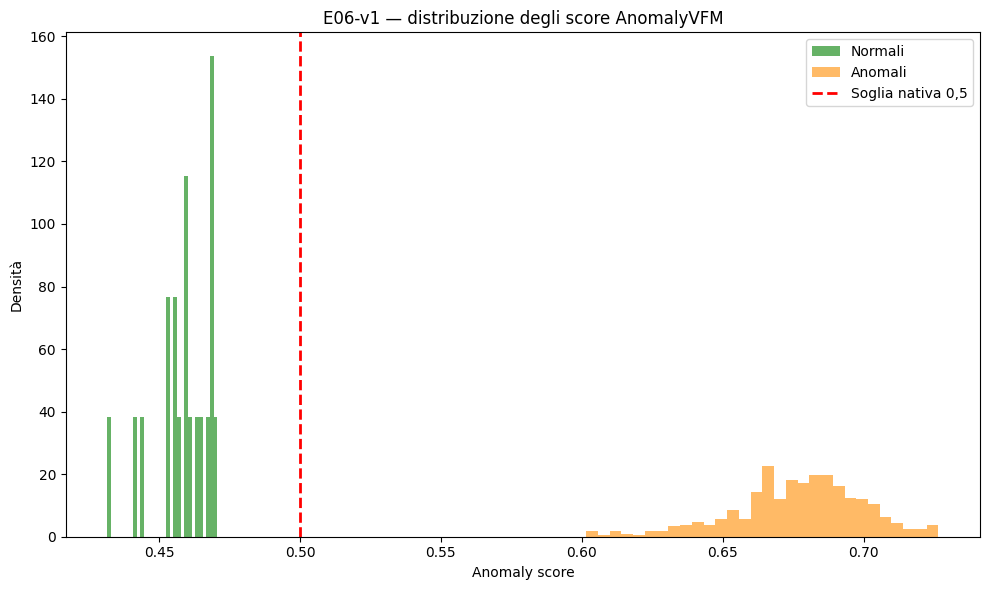

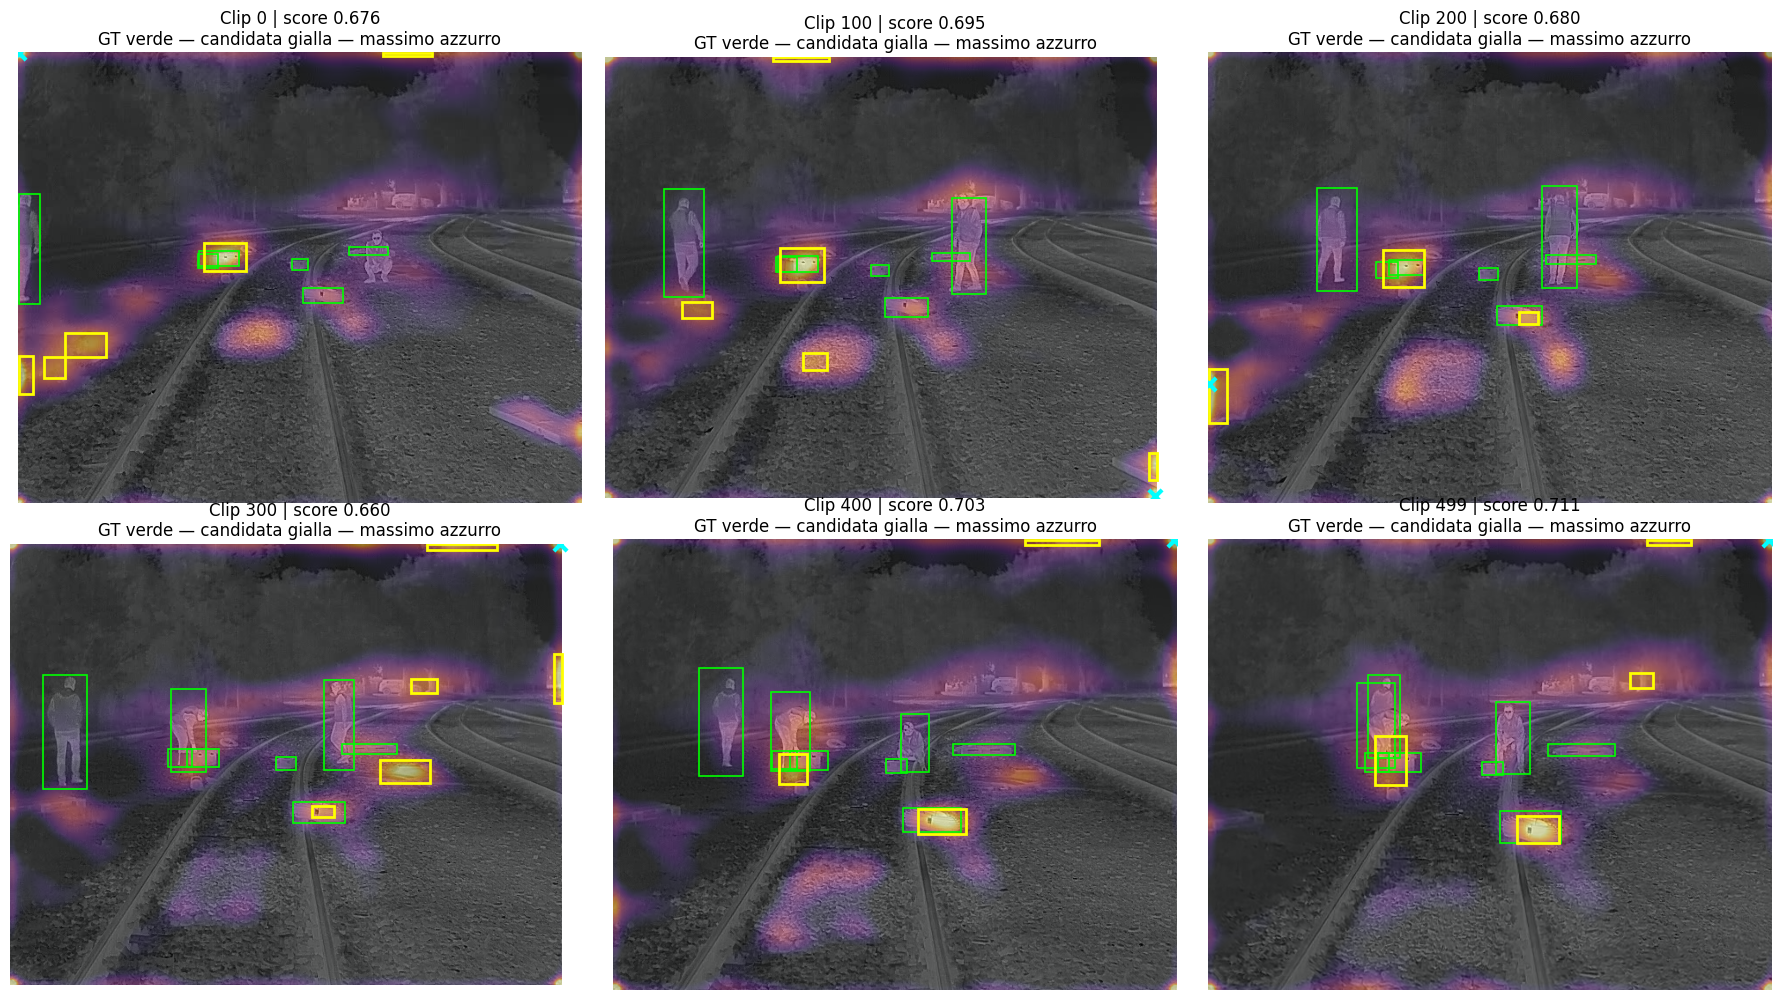

In [12]:
from matplotlib.patches import Rectangle

# Distribuzione score di frame
plt.figure(figsize=(10, 6))

for role, color, label in [
    ("normal_test", "green", "Normali"),
    ("anomaly_test", "darkorange", "Anomali"),
]:
    values = scores_df.loc[
        scores_df["role"] == role,
        "anomaly_score",
    ]

    plt.hist(
        values,
        bins=30,
        density=True,
        alpha=0.60,
        color=color,
        label=label,
    )

plt.axvline(
    0.5,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Soglia nativa 0,5",
)

plt.xlabel("Anomaly score")
plt.ylabel("Densità")
plt.title("E06-v1 — distribuzione degli score AnomalyVFM")
plt.legend()
plt.tight_layout()
plt.savefig(
    "/kaggle/working/E06_score_distribution.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


# Sei frame qualitativi
selected_clip_frames = [0, 100, 200, 300, 400, 499]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for axis, clip_frame in zip(
    axes.ravel(),
    selected_clip_frames,
):
    source_frame = 2125 + clip_frame

    result_index = scores_df.index[
        (scores_df["role"] == "anomaly_test")
        & (scores_df["source_frame"] == source_frame)
    ][0]

    image = np.array(
        Image.open(
            anomaly_frames_dir
            / f"anomaly_{clip_frame:05d}.jpg"
        ).convert("RGB")
    )
    full_mask = upscale_vfm_mask(
        raw_masks_array[result_index]
    )

    axis.imshow(image)
    axis.imshow(
        full_mask,
        cmap="inferno",
        alpha=0.50,
        vmin=float(np.quantile(full_mask, 0.50)),
        vmax=float(np.quantile(full_mask, 0.999)),
    )

    # Ground truth persona: verde
    frame_gt = person_gt[
        person_gt["frame"] == source_frame
    ]

    for _, box in frame_gt.iterrows():
        axis.add_patch(
            Rectangle(
                (box["xtl"], box["ytl"]),
                box["xbr"] - box["xtl"],
                box["ybr"] - box["ytl"],
                edgecolor="lime",
                facecolor="none",
                linewidth=1.2,
            )
        )

    # Box top 1%: giallo
    frame_candidates = candidate_boxes_df[
        (
            candidate_boxes_df["method"]
            == "frame_adaptive_top1pct"
        )
        & (
            candidate_boxes_df["source_frame"]
            == source_frame
        )
    ]

    for _, box in frame_candidates.iterrows():
        axis.add_patch(
            Rectangle(
                (box["xtl"], box["ytl"]),
                box["xbr"] - box["xtl"],
                box["ybr"] - box["ytl"],
                edgecolor="yellow",
                facecolor="none",
                linewidth=2,
            )
        )

    point = pointing_df[
        pointing_df["source_frame"] == source_frame
    ].iloc[0]

    axis.scatter(
        point["max_x"],
        point["max_y"],
        marker="x",
        s=90,
        linewidths=3,
        color="cyan",
    )

    score = scores_df.loc[
        result_index,
        "anomaly_score",
    ]

    axis.set_title(
        f"Clip {clip_frame} | score {score:.3f}\n"
        "GT verde — candidata gialla — massimo azzurro"
    )
    axis.axis("off")

plt.tight_layout()
plt.savefig(
    "/kaggle/working/E06_anomalyvfm_qualitative_six_frames.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()

In [13]:
from pathlib import Path
from IPython.display import FileLink, display
import hashlib
import json
import platform
import shutil
import subprocess
import sys
import zipfile
import pandas as pd
import torch

WORK = Path("/kaggle/working")
NAME = "E06_v1_anomalyvfm_dinov2_zero_shot_results"
BUNDLE = WORK / NAME
ZIP_PATH = WORK / f"{NAME}.zip"

if BUNDLE.exists():
    shutil.rmtree(BUNDLE)
BUNDLE.mkdir()

# Copia tutti gli output E06 prodotti dal notebook
for source in WORK.glob("E06_*"):
    if source.is_file() and source != ZIP_PATH:
        shutil.copy2(source, BUNDLE / source.name)

# Copia GT e manifest degli input
INPUT_BASE = Path(
    "/kaggle/input/datasets/michelerais/"
    "thermal-thesis-e06-inputs/E05_inputs"
)

extra_files = {
    INPUT_BASE / "annotations/test_video_san_donato_v2_reviewed_boxes.csv":
        "ground_truth_boxes.csv",
    INPUT_BASE / "normal_reference/frames.csv":
        "normal_frames_manifest.csv",
}

for source, destination in extra_files.items():
    if source.exists():
        shutil.copy2(source, BUNDLE / destination)

def sha256_file(path):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

# Statistiche degli score
scores_path = BUNDLE / "E06_scores.csv"
if scores_path.exists():
    scores = pd.read_csv(scores_path)
    score_column = next(
        column for column in scores.columns
        if column.lower() in {"score", "anomaly_score"}
    )
    statistics = (
        scores.groupby("role")[score_column]
        .agg(["count", "min", "median", "mean", "max"])
        .reset_index()
    )
    statistics.to_csv(
        BUNDLE / "E06_score_statistics.csv",
        index=False
    )

# Provenienza dei pesi
weight_hashes = {}

weight_locations = {
    "anomalyvfm_model": list(
        Path("/root/.cache/huggingface/hub").rglob("model.safetensors")
    ),
    "dinov2_backbone": list(
        Path("/root/.cache/torch/hub/checkpoints").glob(
            "dinov2_vitl14_reg4_pretrain.pth"
        )
    ),
}

for label, candidates in weight_locations.items():
    if candidates:
        resolved = candidates[0].resolve()
        weight_hashes[label] = {
            "filename": resolved.name,
            "sha256": sha256_file(resolved),
        }

metadata = {
    "experiment_id": "E06_v1_anomalyvfm_dinov2_zero_shot",
    "date": "2026-07-05",
    "method": "AnomalyVFM DINOv2",
    "protocol": "true zero-shot; no normal references or calibration",
    "repository": {
        "url": "https://github.com/MaticFuc/AnomalyVFM",
        "commit": "4da96b493a0b12e4e380fa5bf6573c126342855c",
    },
    "model": {
        "huggingface_id": "MaticFuc/anomalyvfm_dinov2",
        "revision": "c7698cefc6415ca43c93c3e924e02f6863c57e73",
        "parameters": 339847171,
        "weight_hashes": weight_hashes,
    },
    "input": {
        "package": "E05_anomalydino_inputs_v1.zip",
        "package_sha256":
            "db8118fc4517456677418d9db463716aa107a457291ea3d130f8e29600141c2c",
        "normal_test_frames": 20,
        "anomaly_test_frames": 500,
    },
    "classification": {
        "threshold": 0.5,
        "tn": 20,
        "fp": 0,
        "fn": 0,
        "tp": 500,
        "precision": 1.0,
        "recall": 1.0,
        "f1": 1.0,
        "auroc": 1.0,
        "average_precision": 1.0,
        "inference_seconds": 702.483018,
        "frames_per_second": 0.740231,
    },
    "pointing_game": {
        "person_hits": 7,
        "person_frames": 500,
        "person_accuracy": 0.014,
        "all_annotations_hits": 65,
        "all_annotations_accuracy": 0.130,
    },
    "adaptive_box_localization": {
        "quantile": 0.99,
        "minimum_component_area": 200,
        "iou_0.3": {
            "precision": 0.281159,
            "recall": 0.155949,
            "f1": 0.200620,
        },
        "iou_0.5": {
            "precision": 0.1,
            "recall": 0.055466,
            "f1": 0.071355,
        },
    },
    "hardware": {
        "gpu": torch.cuda.get_device_name(0),
        "available_gpus": torch.cuda.device_count(),
        "pytorch": torch.__version__,
        "python": platform.python_version(),
    },
    "limitations": [
        "Normal and anomalous frames come from different railway scenes.",
        "Perfect frame classification may be influenced by scene/domain shift.",
        "Frames from the anomaly video are temporally correlated.",
        "Native masks at threshold 0.5 are empty.",
        "The model score separates the scenes but does not reliably localize people.",
    ],
}

with open(BUNDLE / "metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2, ensure_ascii=False)

readme = """# E06 — AnomalyVFM DINOv2 zero-shot

AnomalyVFM è stato valutato senza immagini normali di riferimento e senza
calibrazione sul dominio ferroviario termico.

## Risultato principale

La soglia nativa 0.5 separa tutti i 20 frame normali dai 500 frame anomali.
Questo risultato non dimostra però una localizzazione corretta: i due insiemi
provengono da scene differenti e le mappe evidenziano spesso massicciata,
bordi e altri elementi dello scenario.

Pointing accuracy sulle persone: 7/500 = 1.4%.

Localizzazione adattiva top 1%:
- F1 IoU 0.3: 0.200620
- F1 IoU 0.5: 0.071355

I file video sorgente non sono duplicati nell'archivio. Sono identificati dal
nome e dall'hash SHA-256 del pacchetto di input registrato in metadata.json.
"""

(BUNDLE / "README.md").write_text(readme, encoding="utf-8")

# Ambiente software
freeze = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True,
    check=True,
)
(BUNDLE / "environment.txt").write_text(
    freeze.stdout,
    encoding="utf-8"
)

# Manifest con hash di tutti i file
manifest = []
for path in sorted(BUNDLE.iterdir()):
    if path.is_file():
        manifest.append({
            "file": path.name,
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        })

with open(BUNDLE / "manifest.json", "w", encoding="utf-8") as file:
    json.dump(manifest, file, indent=2)

# Creazione ZIP
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(BUNDLE.iterdir()):
        archive.write(path, arcname=f"{NAME}/{path.name}")

print("Archivio creato:", ZIP_PATH)
print("Dimensione:", round(ZIP_PATH.stat().st_size / 1024**2, 2), "MB")
print("SHA-256:", sha256_file(ZIP_PATH))
display(FileLink(str(ZIP_PATH)))

Archivio creato: /kaggle/working/E06_v1_anomalyvfm_dinov2_zero_shot_results.zip
Dimensione: 10.03 MB
SHA-256: 9175e8f87e2c2a1db6b5bf74e5150020e70ca8be0c46f9c9d8a56afe7dd3d864


/kaggle/working/E06_v1_anomalyvfm_dinov2_zero_shot_results.zip